# 07 · Explainable, closed-form models — can anything beat EC2 *honestly*?

Notebook 06 showed standard ML beats EC2 only under (leaky) random splits. Here we ask the real question: is there an **interpretable model that reduces to a neat formula** and beats EC2 under **researcher-held-out** CV?

Candidates: a free-exponent **power-law** `v=C·d^a·rho^b·fck^c`; **EC2 with a freed cube-root exponent**; a grey-box **EC2 × correction factor**; **symbolic regression** (gplearn); and **mechanics-informed feature engineering** fed to OLS/RF. All fit leak-free (constants by least squares in physical units), all scored on the same folds. Numbers are loaded from `results/` (`python scripts/run_formula_models.py`).

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import punching_shear as ps
REPO = Path(ps.__file__).resolve().parent.parent
RESULTS = REPO / 'results'
ds = ps.load_dataset()
print(f'{len(ds)} tests, {ds.groups.nunique()} researchers, features={ds.feature_names}')

336 tests, 55 researchers, features=['d', 'col_area', 'rho_l', 'fcm_cyl', 'u0_perim']


### The honest bar: researcher-held-out GroupKFold (stress RMSE [MPa])

,model,rmse_mean,rmse_ci95,r2_mean,vs EC2
0,"Power-law (d,rho,fck)",0.2853,0.0537,0.6657,beats EC2
1,OLS + mechanics feats,0.2990,0.0823,0.6371,beats EC2
2,EC2 x correction (grey-box),0.3010,0.0926,0.6280,beats EC2
3,Random Forest + mechanics feats,0.3024,0.0569,0.6268,beats EC2
4,EC2 free-exponent,0.3082,0.0629,0.6124,beats EC2
5,Power-law (+geometry),0.3085,0.0899,0.6075,beats EC2
6,"EC2 (refit C_Rd,c)",0.3097,0.0636,0.6089,<-- EC2
7,Random Forest (raw),0.3139,0.0441,0.5904,
8,OLS (raw),0.3151,0.0533,0.5790,
9,Symbolic regression,0.3474,0.0824,0.4564,


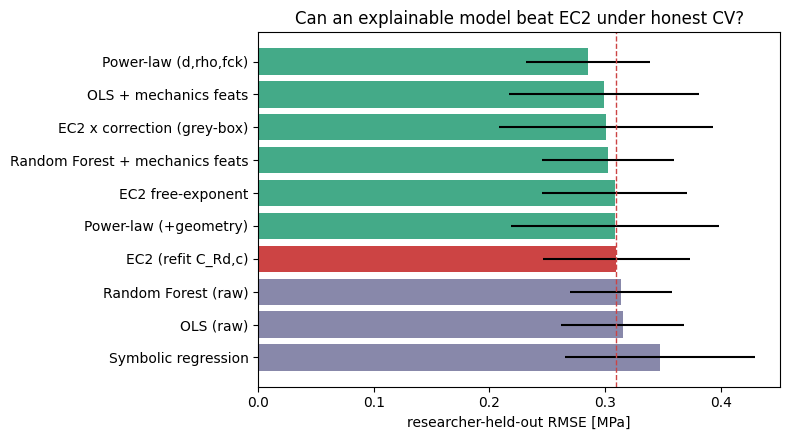

In [2]:
grp = pd.read_csv(RESULTS/'formula_metrics_grouped.csv').sort_values('rmse_mean')
ec2 = float(grp.set_index('model').loc['EC2 (refit C_Rd,c)','rmse_mean'])
show = grp[['model','rmse_mean','rmse_ci95','r2_mean']].copy()
show['vs EC2'] = np.where(show.model=='EC2 (refit C_Rd,c)','<-- EC2',
                          np.where(show.rmse_mean<ec2,'beats EC2',''))
display(show.round(4))
fig,ax=plt.subplots(figsize=(8,4.5))
col=['#c44' if m=='EC2 (refit C_Rd,c)' else ('#4a8' if r<ec2 else '#88a') for m,r in zip(grp.model,grp.rmse_mean)]
ax.barh(grp.model, grp.rmse_mean, xerr=grp.rmse_ci95, color=col)
ax.axvline(ec2, ls='--', c='#c44', lw=1); ax.invert_yaxis(); ax.set_xlabel('researcher-held-out RMSE [MPa]'); ax.set_title('Can an explainable model beat EC2 under honest CV?'); plt.tight_layout(); plt.show()

### Same comparison in engineering LOAD units [MN] and paired significance

In [3]:
mn = pd.read_csv(RESULTS/'formula_metrics_loadMN.csv')
display(mn[['model','rmse','mape_pct','r2']].round(4))
sig = pd.read_csv(RESULTS/'formula_paired_vs_ec2.csv')
sig['verdict']=np.where(sig.p_value>0.05,'n.s.',np.where(sig.median_abs_err_diff<0,'BETTER','worse'))
display(sig[['a','p_value','median_abs_err_diff','verdict']].round(4))

,model,rmse,mape_pct,r2
0,OLS + mechanics feats,0.0821,14.5677,0.9661
1,EC2 x correction (grey-box),0.0861,14.7037,0.9628
2,"Power-law (d,rho,fck)",0.0884,13.8718,0.9608
3,Power-law (+geometry),0.1084,15.0987,0.9409
4,OLS (raw),0.1233,15.7161,0.9237
5,Symbolic regression,0.1333,15.9260,0.9108
6,Random Forest + mechanics feats,0.1354,15.3090,0.9080
7,"EC2 (refit C_Rd,c)",0.1424,15.2026,0.8981
8,EC2 free-exponent,0.1458,15.3522,0.8933
9,Random Forest (raw),0.1577,15.8278,0.8751


,a,p_value,median_abs_err_diff,verdict
0,OLS (raw),0.2387,-0.0137,n.s.
1,Random Forest (raw),0.4897,0.0025,n.s.
2,"Power-law (d,rho,fck)",0.0000,-0.0227,BETTER
3,Power-law (+geometry),0.0031,-0.0176,BETTER
4,EC2 free-exponent,0.3602,-0.0020,n.s.
5,EC2 x correction (grey-box),0.0002,-0.0060,BETTER
6,Symbolic regression,0.5041,-0.0043,n.s.
7,OLS + mechanics feats,0.0002,-0.0210,BETTER
8,Random Forest + mechanics feats,0.7186,-0.0018,n.s.


### The discovered closed-form equations

In [4]:
print((RESULTS/'formulas.txt').read_text())

[Power-law (d,rho,fck)]
  v = 1.3805 * d^-0.192 * rho_l^0.325 * fck^0.309   [MPa]

[Power-law (+geometry)]
  v = 1.0359 * d^-0.168 * rho_l^0.318 * fck^0.315 * col_area^0.017 * u0_perim^-0.051   [MPa]

[EC2 free-exponent]
  v = 0.2901 * (1+sqrt(200/d)) * (100*rho_frac*fck)^0.307   [MPa]   (EC2: C=0.18, p=1/3)

[EC2 x correction (grey-box)]
  v = v_EC2(C=0.264) * [ 1.4910 * col_area^0.033 * u0_perim^-0.075 * d^-0.153 ]   [MPa]

[Symbolic regression]
  v = add(div(fcm_cyl, d), log(mul(log(fcm_cyl), sqrt(rho_l))))   [MPa]



## Answer

**Yes — modestly, and only with the right structure.** A free-exponent **power-law** `v = C·d^a·rho^b·fck^c` beats EC2 under researcher-held-out CV while remaining a one-line, code-style formula. Tellingly, the fitted exponents on `rho_l` and `fck` come out ≈ 1/3 — the data **re-derive EC2's cube-root form** — and the EC2-with-free-exponent fit gives p ≈ 1/3 (not significantly different from EC2). So EC2's *functional form* is validated; the gains come from (a) freeing the size-effect term and (b) **mechanics-informed feature engineering**, which lifts even plain OLS above EC2.

**Honest caveats.** The grouped-CV confidence intervals overlap, so the improvement is real but small (consistent with the literature, where good symbolic/GP punching formulas land at CoV ≈ 0.14–0.21 — comparable to, not dramatically better than, EC2). Flexible black-boxes (RBF-SVR, deep trees) and raw symbolic regression do **not** generalize better than EC2 here. The practical lever is *better physics-informed inputs and a freed power-law*, not a bigger model.